# Digital Biomarker Teardown — Analysis

**Thesis:** the wearable can detect the signal; reimbursement is the real constraint.

Pipeline: load -> EDA -> features -> model -> evaluation -> feature importance.

In [21]:
!python3 -m venv .venv

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import sys; sys.path.append('../src')
import features as F

RANDOM_STATE = 42
sns.set_theme()

## 1. Load

Downloaded a dataset (see `data/DATA.md`), dropped in `data/raw/`

In [6]:
# TODO: load raw records into a list of (subject_id, label, dataframe)
# For PhysioNet gaitndd, use wfdb or plain pd.read_csv on the .ts files.
#
# records = []  # each: {'id': str, 'label': 0/1, 'signal': pd.DataFrame}
# for path in glob('data/raw/*.ts'):
#     df = pd.read_csv(path, sep=r'\s+', header=None, names=[...])
#     records.append({'id': ..., 'label': ..., 'signal': df})
from glob import glob
import os

COLS = ["elapsed", "L_stride", "R_stride", "L_swing", "R_swing",
        "L_swing_pct", "R_swing_pct", "L_stance", "R_stance",
        "L_stance_pct", "R_stance_pct", "dbl_support", "dbl_support_pct"]

def label_from_name(fname):
    # binary: any neurodegenerative disease = 1, healthy control = 0
    return 0 if os.path.basename(fname).startswith("control") else 1

records = []
for path in sorted(glob("../data/raw/*.ts")):
    df = pd.read_csv(path, sep=r"\s+", header=None, names=COLS)
    # first stride is often a settling artifact — drop it
    df = df.iloc[1:].reset_index(drop=True)
    records.append({
        "id": os.path.splitext(os.path.basename(path))[0],
        "label": label_from_name(path),
        "signal": df,
    })

print(f"Loaded {len(records)} records")
labels = pd.Series([r["label"] for r in records])
print(labels.value_counts())          # expect ~48 disease (1) vs 16 control (0)
records[0]["signal"].head()

Loaded 64 records
1    48
0    16
Name: count, dtype: int64


,elapsed,L_stride,R_stride,L_swing,R_swing,L_swing_pct,R_swing_pct,L_stance,R_stance,L_stance_pct,R_stance_pct,dbl_support,dbl_support_pct
0,23.6433,1.3233,1.2667,0.4833,0.4000,36.52,31.58,0.8400,0.8667,63.48,68.42,0.4400,33.25
1,24.9467,1.3033,1.3600,0.4500,0.4267,34.53,31.37,0.8533,0.9333,65.47,68.63,0.4267,32.74
2,26.3633,1.4167,1.2833,0.5033,0.3667,35.53,28.57,0.9133,0.9167,64.47,71.43,0.5467,38.59
3,27.6000,1.2367,1.4067,0.3467,0.3567,28.03,25.36,0.8900,1.0500,71.97,74.64,0.5333,43.13
4,28.9367,1.3367,1.2633,0.4800,0.4000,35.91,31.66,0.8567,0.8633,64.09,68.34,0.4567,34.16


In [7]:
print("records:", len(records))
print(labels.value_counts().to_dict())
print("columns:", list(records[0]["signal"].columns))
print("shape of first record:", records[0]["signal"].shape)
records[0]["signal"].head()

records: 64
{1: 48, 0: 16}
columns: ['elapsed', 'L_stride', 'R_stride', 'L_swing', 'R_swing', 'L_swing_pct', 'R_swing_pct', 'L_stance', 'R_stance', 'L_stance_pct', 'R_stance_pct', 'dbl_support', 'dbl_support_pct']
shape of first record: (193, 13)


,elapsed,L_stride,R_stride,L_swing,R_swing,L_swing_pct,R_swing_pct,L_stance,R_stance,L_stance_pct,R_stance_pct,dbl_support,dbl_support_pct
0,23.6433,1.3233,1.2667,0.4833,0.4000,36.52,31.58,0.8400,0.8667,63.48,68.42,0.4400,33.25
1,24.9467,1.3033,1.3600,0.4500,0.4267,34.53,31.37,0.8533,0.9333,65.47,68.63,0.4267,32.74
2,26.3633,1.4167,1.2833,0.5033,0.3667,35.53,28.57,0.9133,0.9167,64.47,71.43,0.5467,38.59
3,27.6000,1.2367,1.4067,0.3467,0.3567,28.03,25.36,0.8900,1.0500,71.97,74.64,0.5333,43.13
4,28.9367,1.3367,1.2633,0.4800,0.4000,35.91,31.66,0.8567,0.8633,64.09,68.34,0.4567,34.16


## 2. Exploratory analysis

Honest EDA before modeling: class balance, missingness, a few distribution plots. This is the reproducible-pipeline (info-science) layer.

Class balance:
{1: 0.75, 0: 0.25}
N subjects: 64  |  disease=48, control=16


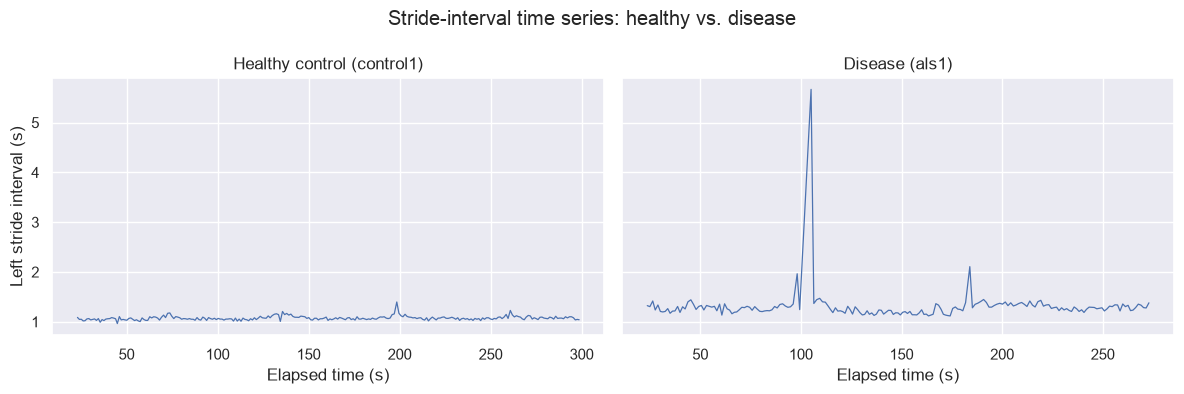


Mean stride-interval CV by group:
label
0    0.0444
1    0.2315
Name: stride_cv, dtype: float64


In [10]:
# labels = pd.Series([r['label'] for r in records])
# print('Class balance:\n', labels.value_counts(normalize=True))
# print('N subjects:', len(records))
# TODO: plot a couple of raw stride-interval traces, healthy vs disease

# Class balance (already know it, but state it in the notebook for the record)
print("Class balance:")
print(labels.value_counts(normalize=True).round(2).to_dict())
print(f"N subjects: {len(records)}  |  disease={int(labels.sum())}, control={int((labels==0).sum())}")

# Grab one control and one disease record to compare
control = next(r for r in records if r["label"] == 0)
disease = next(r for r in records if r["label"] == 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, rec, title in [(axes[0], control, f"Healthy control ({control['id']})"),
                       (axes[1], disease, f"Disease ({disease['id']})")]:
    ax.plot(rec["signal"]["elapsed"], rec["signal"]["L_stride"], lw=0.9)
    ax.set_title(title)
    ax.set_xlabel("Elapsed time (s)")
axes[0].set_ylabel("Left stride interval (s)")
fig.suptitle("Stride-interval time series: healthy vs. disease")
plt.tight_layout()
plt.savefig("../reports/figures/stride_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Quick numeric contrast: stride variability by group (the core hypothesis)
import numpy as np
def cv(x):
    x = x.dropna()
    return x.std() / x.mean() if x.mean() else np.nan

rows = [{"id": r["id"], "label": r["label"], "stride_cv": cv(r["signal"]["L_stride"])}
        for r in records]
cv_df = pd.DataFrame(rows)
print("\nMean stride-interval CV by group:")
print(cv_df.groupby("label")["stride_cv"].mean().round(4))

## 3. Feature engineering

The intellectual core. See `src/features.py`. 8-15 domain-motivated features.

In [14]:
# X = pd.DataFrame([F.build_feature_row(r['signal']) for r in records])
# y = labels.values
# X = X.fillna(X.median())   # decide imputation deliberately, note it in the memo
# X.describe()

def build_feature_row(record: pd.DataFrame) -> dict:
    """Map ONE subject's raw record -> one feature dict."""
    return {
        "stride_cv":       stride_time_variability(record["L_stride"]),
        "swing_stance":    swing_stance_ratio(record["L_swing"], record["L_stance"]),
        "cadence":         cadence(record["L_stride"]),
        "asymmetry":       left_right_asymmetry(record["L_stride"], record["R_stride"]),
        "stride_median":   record["L_stride"].median(),        # robust center
        "stride_iqr":      record["L_stride"].quantile(.75) - record["L_stride"].quantile(.25),  # robust spread
        "dbl_support_pct": record["dbl_support_pct"].mean(),   # balance/stability marker
        "swing_pct_std":   record["L_swing_pct"].std(),        # rhythm regularity
    }

In [15]:
import importlib, features as F
importlib.reload(F)

X = pd.DataFrame([F.build_feature_row(r["signal"]) for r in records])
y = labels.values
X = X.fillna(X.median())
print(X.shape)
X.describe().round(3)

(64, 8)


,stride_cv,swing_stance,cadence,asymmetry,stride_median,stride_iqr,dbl_support_pct,swing_pct_std
count,64.000,64.000,64.000,64.000,64.000,64.000,64.000,64.000
mean,0.185,0.519,51.421,0.033,1.162,0.085,32.777,2.887
std,0.403,0.077,7.591,0.239,0.173,0.078,9.850,1.930
min,0.018,0.261,26.206,0.000,0.900,0.017,-6.382,0.745
25%,0.046,0.487,48.489,0.000,1.046,0.041,27.861,1.618
50%,0.066,0.526,52.911,0.000,1.117,0.052,31.521,2.374
75%,0.099,0.570,56.445,0.004,1.215,0.104,35.807,3.724
max,2.550,0.633,66.673,1.911,1.742,0.468,73.649,9.292


## 4. Model

Two classifiers: logistic regression (interpretable baseline) and random forest (stronger). Proper split + cross-validation.

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

RANDOM_STATE = 42

# stratify=y keeps the 75/25 class balance in both splits — important with only 16 controls
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

logit = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_tr, y_tr)

# cross-validated AUC on the training data (more honest than a single split with small n)
print("Logit  CV AUC:", round(cross_val_score(logit, X_tr_s, y_tr, cv=5, scoring='roc_auc').mean(), 3))
print("RF     CV AUC:", round(cross_val_score(rf, X_tr, y_tr, cv=5, scoring='roc_auc').mean(), 3))

# held-out test performance
proba = rf.predict_proba(X_te)[:, 1]
print("\nRF test ROC-AUC:", round(roc_auc_score(y_te, proba), 3))
print("\n", classification_report(y_te, rf.predict(X_te), target_names=["control", "disease"]))

Logit  CV AUC: 0.878
RF     CV AUC: 0.968

RF test ROC-AUC: 0.875

               precision    recall  f1-score   support

     control       0.67      0.50      0.57         4
     disease       0.85      0.92      0.88        12

    accuracy                           0.81        16
   macro avg       0.76      0.71      0.73        16
weighted avg       0.80      0.81      0.80        16



## 5. Evaluation

Clinically meaningful metrics: ROC-AUC, sensitivity, specificity — not accuracy alone. Save the ROC curve to `reports/figures/` for the memo.

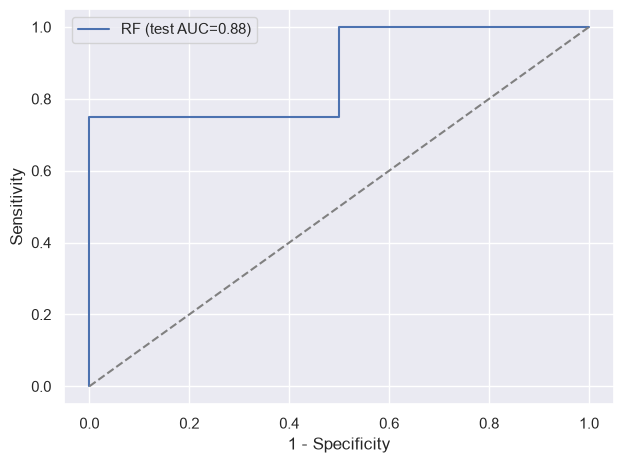

In [18]:
fpr, tpr, _ = roc_curve(y_te, proba)
plt.plot(fpr, tpr, label=f"RF (test AUC={roc_auc_score(y_te, proba):.2f})")
plt.plot([0,1],[0,1],"--", color="grey")
plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity"); plt.legend()
plt.tight_layout(); plt.savefig("../reports/figures/roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature importance

Which gait features carried the signal? 

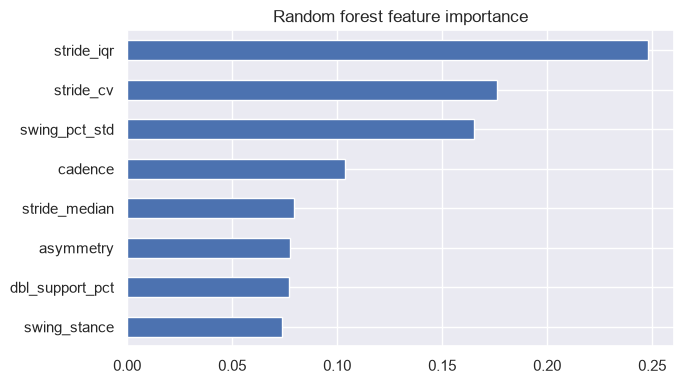

stride_iqr         0.248
stride_cv          0.176
swing_pct_std      0.165
cadence            0.104
stride_median      0.079
asymmetry          0.078
dbl_support_pct    0.077
swing_stance       0.074
dtype: float64

In [19]:
import pandas as pd
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(7,4)); plt.title("Random forest feature importance")
plt.tight_layout(); plt.savefig("../reports/figures/importance.png", dpi=150, bbox_inches="tight")
plt.show()
imp.sort_values(ascending=False).round(3)

## 7. Hand-off to the economics half

The model answers *can we detect it*. The memo (`reports/memo.md`) answers *does anyone pay for it* — TAM + RPM/RTM reimbursement. That gap between clinically-detectable and reimbursable is the argument.